In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, precision_recall_curve,
                             roc_auc_score, classification_report, confusion_matrix)

In [45]:
df = pd.read_csv('credit_risk.csv')

In [46]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Tradução das Variáveis

- **person_income** → Renda anual  
- **person_emp_length** → Tempo de emprego (anos)  
- **person_home_ownership** → Tipo de moradia  
- **loan_intent** → Finalidade do empréstimo  
- **loan_grade** → Grau do empréstimo  
- **loan_amnt** → Valor do empréstimo  
- **loan_status** → Status do empréstimo  
  - `0` = Não inadimplente  
  - `1` = Inadimplente  
- **loan_percent_income** → Percentual da renda comprometida  
- **cb_person_default_on_file** → Histórico de inadimplência  
- **cb_person_cred_hist_length** → Tempo de histórico de crédito  

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [48]:
df.describe().round(3)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000,32581.000,31686.000,32581.000,29465.000,32581.000,32581.000,32581.000
mean,27.735,66074.848,4.790,9589.371,11.012,0.218,0.170,5.804
std,6.348,61983.119,4.143,6322.087,3.240,0.413,0.107,4.055
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000
25%,23.000,38500.000,2.000,5000.000,7.900,0.000,0.090,3.000
50%,26.000,55000.000,4.000,8000.000,10.990,0.000,0.150,4.000
75%,30.000,79200.000,7.000,12200.000,13.470,0.000,0.230,8.000
max,144.000,6000000.000,123.000,35000.000,23.220,1.000,0.830,30.000


In [49]:
print(df.isna().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [50]:
df.shape

(32581, 12)

In [51]:
df.loc[df['person_emp_length'].isna()]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
105,22,12600,MORTGAGE,NaN,PERSONAL,A,2000,5.42,1,0.16,N,4
222,24,185000,MORTGAGE,NaN,EDUCATION,B,35000,12.42,0,0.19,N,2
379,24,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900,NaN,1,0.23,N,3
407,25,52000,RENT,NaN,PERSONAL,B,24000,10.74,1,0.46,N,2
408,22,17352,MORTGAGE,NaN,EDUCATION,C,2250,15.27,0,0.13,Y,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32285,38,12000,OWN,NaN,EDUCATION,A,4800,7.29,1,0.40,N,12
32328,51,18408,RENT,NaN,PERSONAL,C,1000,14.65,1,0.05,Y,20
32360,70,39996,RENT,NaN,MEDICAL,C,3600,15.23,0,0.09,Y,19
32453,56,32400,RENT,NaN,MEDICAL,A,8575,7.51,0,0.26,N,18


In [52]:
print(f"Média: {df['person_emp_length'].median()}, "
      f"Máximo: {df['person_emp_length'].max()}, "
      f"Mínimo: {df['person_emp_length'].min()}, "
      f"Moda: {df['person_emp_length'].mode()[0]}")

Média: 4.0, Máximo: 123.0, Mínimo: 0.0, Moda: 0.0


In [53]:
# Preenche valores ausentes da coluna 'person_emp_length'
# utilizando a mediana, reduzindo impacto de outliers
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

In [54]:
print(df.isna().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [55]:
print(f"Média: {df['loan_int_rate'].median()}, "
      f"Máximo: {df['loan_int_rate'].max()}, "
      f"Mínimo: {df['loan_int_rate'].min()}, "
      f"Moda: {df['loan_int_rate'].mode()[0]}")

Média: 10.99, Máximo: 23.22, Mínimo: 5.42, Moda: 7.51


In [56]:
# Preenche valores ausentes da taxa de juros com a moda,
# utilizando o valor mais frequente da coluna
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].mode()[0])

In [57]:
print(df.isna().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [58]:
# Removendo valores duplicados do dataset
df.drop_duplicates(inplace=True)
len(df)

32416

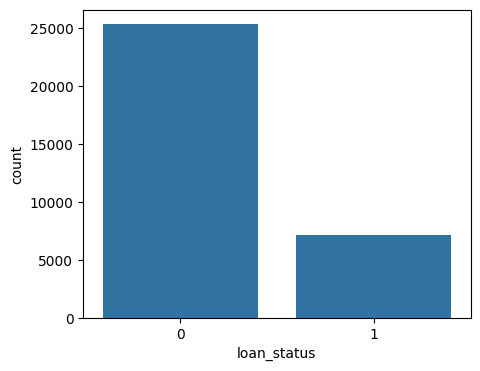

In [59]:
plt.figure(figsize=(5,4))
sns.barplot(df['loan_status'].value_counts())
plt.show()

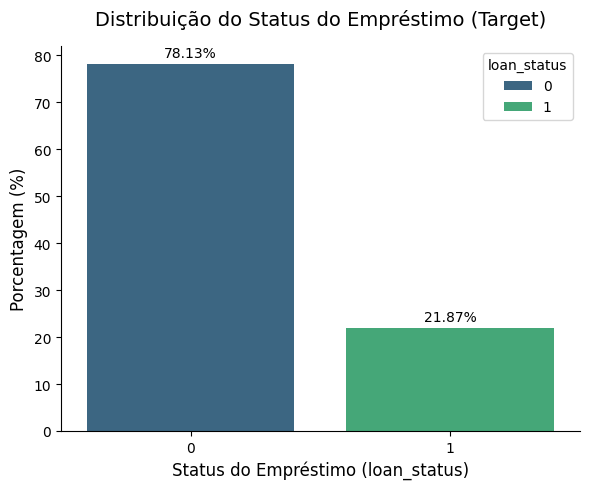

In [60]:
porcentagens = (df['loan_status'].value_counts() / len(df) * 100).round(2)

plt.figure(figsize=(6, 5))

ax = sns.barplot(x=porcentagens.index, y=porcentagens.values, palette='viridis', hue=porcentagens.index)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Distribuição do Status do Empréstimo (Target)', fontsize=14, pad=15)
plt.xlabel('Status do Empréstimo (loan_status)', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)

sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

#📊 **Análise Exploratória dos Dados**

Nesta seção, serão apresentados alguns gráficos para visualizar padrões e relações entre as variáveis do dataset.

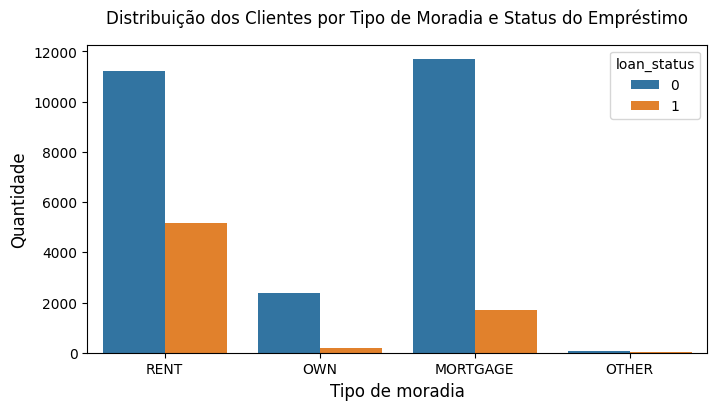

In [61]:
plt.figure(figsize=(8,4))


sns.countplot(x=df['person_home_ownership'], hue=df['loan_status'])

plt.title('Distribuição dos Clientes por Tipo de Moradia e Status do Empréstimo', pad=15)
plt.xlabel('Tipo de moradia', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)

plt.show()

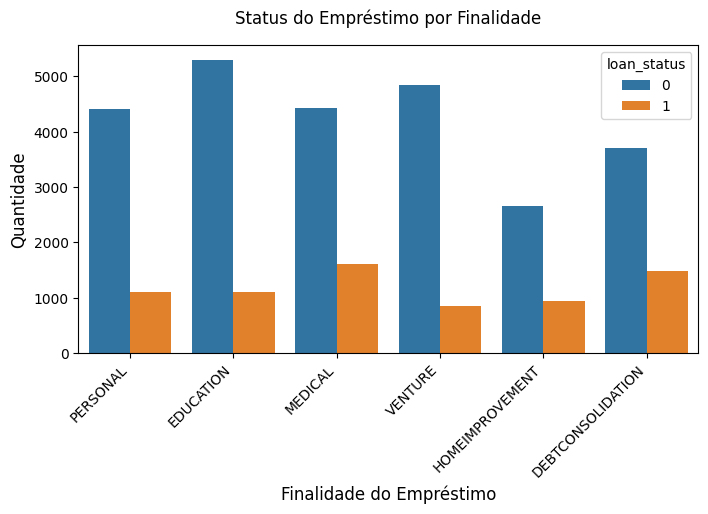

In [62]:
plt.figure(figsize=(8,4))

sns.countplot(x=df['loan_intent'], hue=df['loan_status'])

plt.xticks(rotation=45, ha='right')

plt.title('Status do Empréstimo por Finalidade', pad=15)
plt.xlabel('Finalidade do Empréstimo', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)

plt.show()

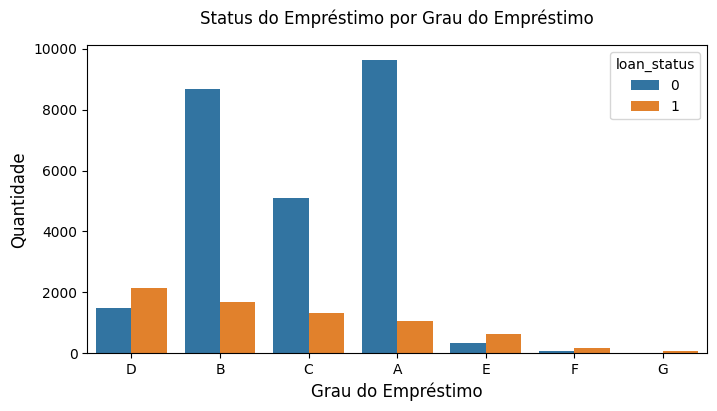

In [63]:
plt.figure(figsize=(8,4))

sns.countplot(x=df['loan_grade'], hue=df['loan_status'])

plt.title('Status do Empréstimo por Grau do Empréstimo', pad=15)
plt.xlabel('Grau do Empréstimo', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)

plt.show()

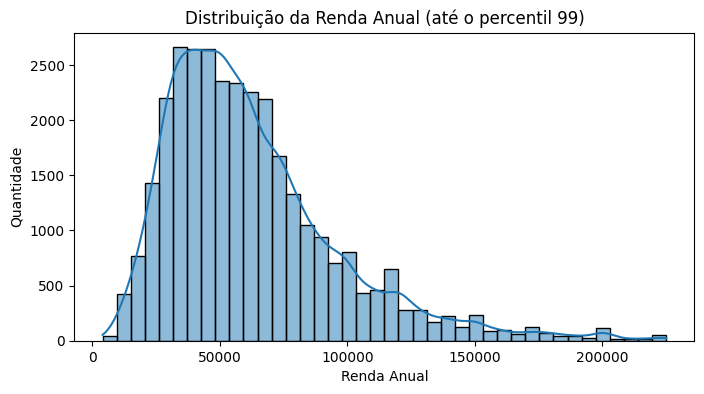

In [64]:
q99 = df['person_income'].quantile(0.99)

plt.figure(figsize=(8,4))

sns.histplot(
    df[df['person_income'] <= q99]['person_income'],
    bins=40,
    kde=True
)

plt.title('Distribuição da Renda Anual (até o percentil 99)')
plt.xlabel('Renda Anual')
plt.ylabel('Quantidade')

plt.show()

In [65]:
col_num = df.select_dtypes(include=['int64', 'float64']).columns

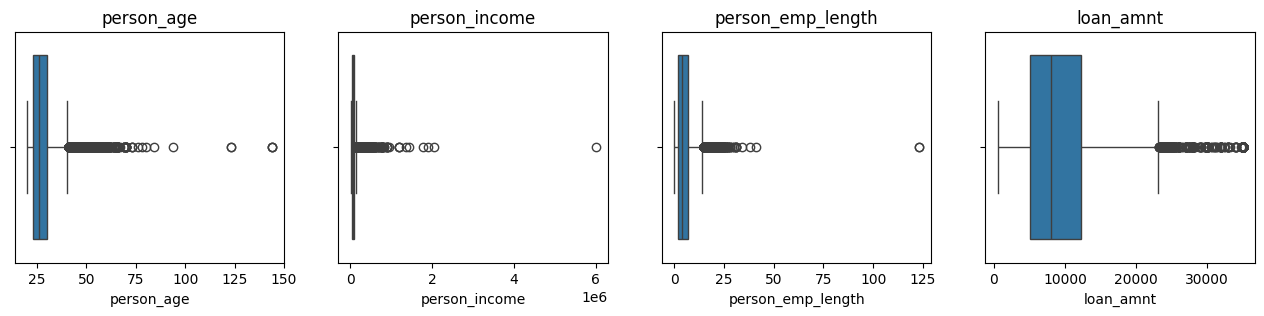

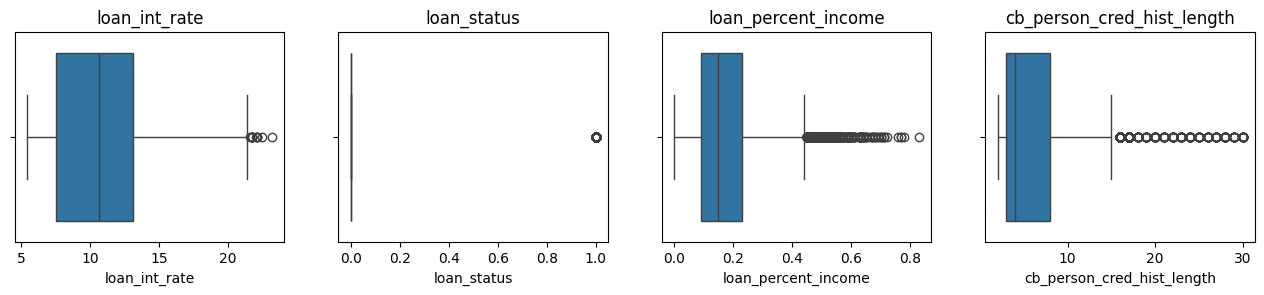

<Figure size 1600x900 with 0 Axes>

In [66]:
coluna = 4
linha = 1

plt.figure(figsize=(16, 3 * linha))

for i, col in enumerate(col_num):

    plt.subplot(linha, coluna, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

    if (i + 1) % coluna == 0:
        linha += 1
        plt.figure(figsize=(16, 3 * linha))

plt.tight_layout()
plt.show()

In [67]:
# Tratando alguns outliers
df = df[(df['person_age'] <=80)]

df = df[(df['person_income'] <= 1000000)]

df = df[(df['person_emp_length'] <= 38.0)]

In [68]:
len(df)

32398

In [69]:
corr = df.corr(numeric_only=True)
corr_target = corr[['loan_status']].sort_values(by='loan_status', ascending=False)

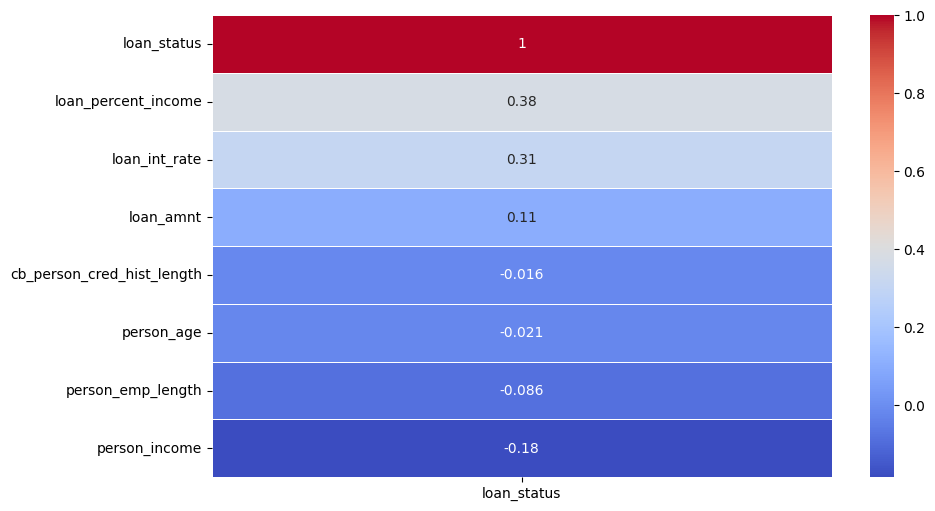

In [70]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.show()

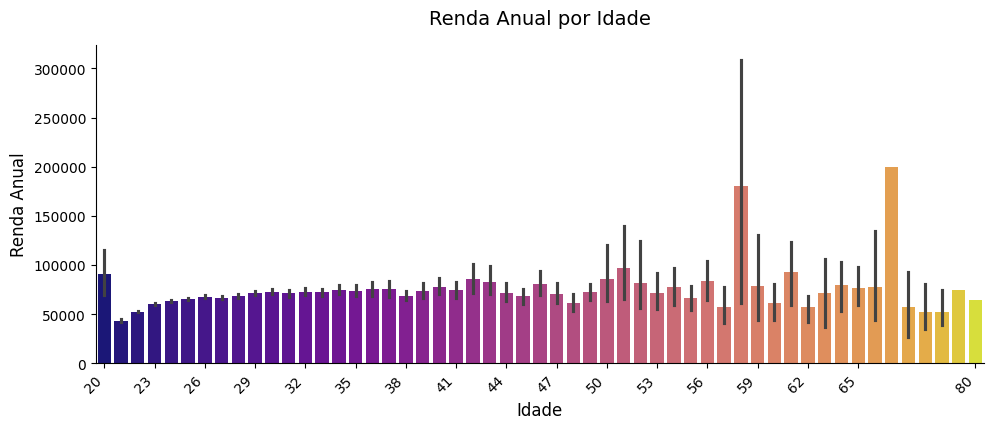

In [71]:
plt.figure(figsize=(10, 4))

df_sorted = df.sort_values('person_age')

sns.barplot(
    data=df_sorted,
    x='person_age',
    y='person_income',
    hue='person_age',
    palette='plasma',
    legend=False
)


idades_unicas = sorted(df['person_age'].unique())


posicoes = []
labels = []

for i, idade in enumerate(idades_unicas):

    if idade >= 20 and (idade - 20) % 3 == 0:
        posicoes.append(i)
        labels.append(idade)

plt.xticks(ticks=posicoes, labels=labels, rotation=45, ha='right')

sns.despine(top=True, right=True)
plt.tight_layout()

plt.title('Renda Anual por Idade', fontsize=14, pad=15)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Renda Anual', fontsize=12)

plt.show()

In [72]:
df.tail(3)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


## Comparação de Modelos

Após a preparação dos dados, será aplicado o Train-Test Split para separar os conjuntos de treino, validação e teste. Diferentes algoritmos de Machine Learning serão avaliados para determinar o modelo mais adequado para prever a inadimplência dos clientes.


In [73]:
from collections import Counter
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [74]:
df_final = df.copy()

In [75]:
X = df_final.drop(columns='loan_status')
y = df_final['loan_status']

In [76]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp)

In [77]:
col_num_x = X_train.select_dtypes(include=['int64', 'float64']).columns

In [78]:
obj_cols = [col for col in df.columns if df[col].dtype == object]

In [79]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200),
    'K Neighbors': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42)
}

In [80]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), col_num_x),
        ('encoder', OneHotEncoder(drop='first'), obj_cols)
    ]
)


📌 Modelo: Logistic Regression

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.87      3797
           1       0.55      0.77      0.65      1063

    accuracy                           0.81      4860
   macro avg       0.74      0.80      0.76      4860
weighted avg       0.85      0.81      0.82      4860


🔹 Acurácia: 0.8144




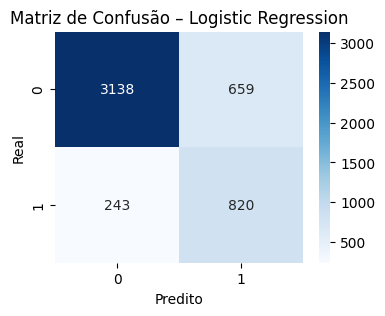


📌 Modelo: Decision Tree

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      3797
           1       0.71      0.78      0.74      1063

    accuracy                           0.88      4860
   macro avg       0.82      0.84      0.83      4860
weighted avg       0.89      0.88      0.88      4860


🔹 Acurácia: 0.8805




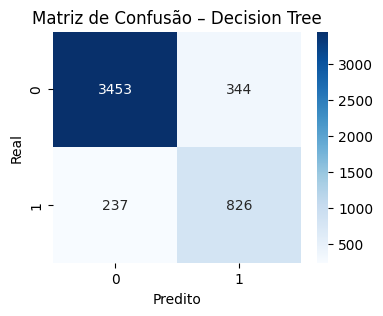


📌 Modelo: Random Forest

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      3797
           1       0.93      0.74      0.82      1063

    accuracy                           0.93      4860
   macro avg       0.93      0.86      0.89      4860
weighted avg       0.93      0.93      0.93      4860


🔹 Acurácia: 0.9294




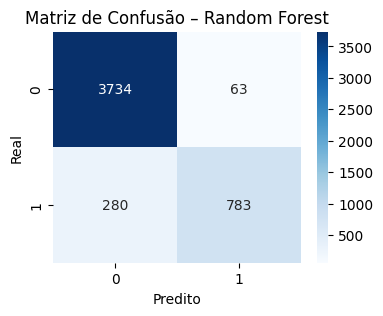


📌 Modelo: K Neighbors

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      3797
           1       0.54      0.77      0.64      1063

    accuracy                           0.81      4860
   macro avg       0.74      0.80      0.75      4860
weighted avg       0.84      0.81      0.82      4860


🔹 Acurácia: 0.8091




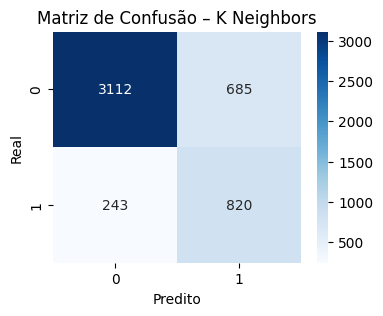


📌 Modelo: XGBoost

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      3797
           1       0.95      0.73      0.83      1063

    accuracy                           0.93      4860
   macro avg       0.94      0.86      0.89      4860
weighted avg       0.94      0.93      0.93      4860


🔹 Acurácia: 0.9342




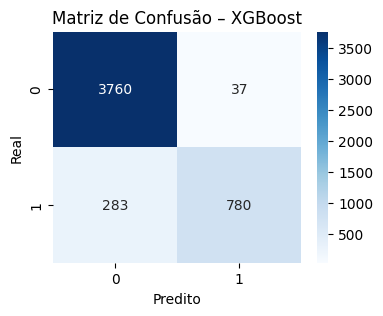

In [81]:
for name, clf in models.items():

  model = ImbPipeline(steps=[
      ('preprocessor', preprocessor),
      ('smote', SMOTE()),
      ('model', clf)
  ])

  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)

  acc = accuracy_score(y_val, y_pred)
  conf_matix = confusion_matrix(y_val, y_pred)

  print("\n" + "="*60)
  print(f"📌 Modelo: {name}")
  print("="*60)

  print("\n🔹 Classification Report:")
  print(classification_report(y_val, y_pred))
  print(f"\n🔹 Acurácia: {acc:.4f}")
  print("\n")

  plt.figure(figsize=(4,3))
  sns.heatmap(conf_matix, annot=True, fmt="d", cmap="Blues")
  plt.title(f"Matriz de Confusão – {name}")
  plt.xlabel("Predito")
  plt.ylabel("Real")
  plt.show()


📌 Modelo: Logistic Regression

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.87      3797
           1       0.56      0.77      0.65      1063

    accuracy                           0.82      4860
   macro avg       0.74      0.80      0.76      4860
weighted avg       0.85      0.82      0.82      4860


🔹 Acurácia: 0.8150




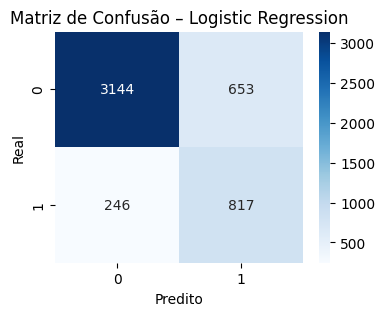


📌 Modelo: Decision Tree

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      3797
           1       0.68      0.78      0.73      1063

    accuracy                           0.87      4860
   macro avg       0.81      0.84      0.82      4860
weighted avg       0.88      0.87      0.88      4860


🔹 Acurácia: 0.8720




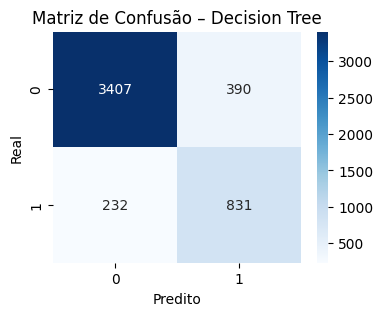


📌 Modelo: Random Forest

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      3797
           1       0.93      0.74      0.82      1063

    accuracy                           0.93      4860
   macro avg       0.93      0.86      0.89      4860
weighted avg       0.93      0.93      0.93      4860


🔹 Acurácia: 0.9302




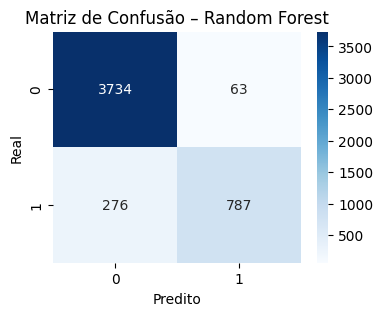


📌 Modelo: K Neighbors

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      3797
           1       0.54      0.76      0.63      1063

    accuracy                           0.81      4860
   macro avg       0.73      0.79      0.75      4860
weighted avg       0.84      0.81      0.82      4860


🔹 Acurácia: 0.8070




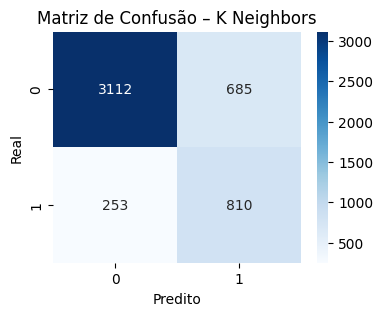


📌 Modelo: XGBoost

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      3797
           1       0.95      0.75      0.84      1063

    accuracy                           0.94      4860
   macro avg       0.94      0.87      0.90      4860
weighted avg       0.94      0.94      0.93      4860


🔹 Acurácia: 0.9364




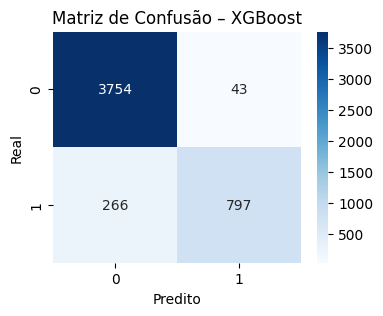

In [82]:
for name, clf in models.items():

  model = ImbPipeline(steps=[
      ('preprocessor', preprocessor),
      ('smote', SMOTE()),
      ('model', clf)
  ])

  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)

  acc = accuracy_score(y_val, y_pred)
  conf_matix = confusion_matrix(y_val, y_pred)

  print("\n" + "="*60)
  print(f"📌 Modelo: {name}")
  print("="*60)

  print("\n🔹 Classification Report:")
  print(classification_report(y_val, y_pred))
  print(f"\n🔹 Acurácia: {acc:.4f}")
  print("\n")

  plt.figure(figsize=(4,3))
  sns.heatmap(conf_matix, annot=True, fmt="d", cmap="Blues")
  plt.title(f"Matriz de Confusão – {name}")
  plt.xlabel("Predito")
  plt.ylabel("Real")
  plt.show()

## Escolha do Modelo

Com base nos resultados obtidos, o XGBoost apresentou o melhor equilíbrio entre Precision, Recall, F1-Score e Acurácia na **MACRO AVG**. Portanto, ele foi escolhido como modelo final para a etapa de otimização de hiperparâmetros.

| Modelo              | Precision | Recall | F1-Score | Acurácia |
| ------------------- | --------- | ------ | -------- | -------- |
| Logistic Regression | 0.74      | 0.80   | 0.76     | 0.8150   |
| Decision Tree       | 0.81      | 0.84   | 0.82     | 0.8720   |
| Random Forest       | 0.93      | 0.86   | 0.89     | 0.9302  |
| KNN                 | 0.74      | 0.79   | 0.75     | 0.8070   |
| **XGBoost**         | **0.94**  | **0.87** | **0.90**| **0.9364**  |


In [83]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

📌 Modelo: XGBoost
Acurácia de: 0.9354

ROC-AUC: 0.9415

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      3797
           1       0.97      0.73      0.83      1063

    accuracy                           0.94      4860
   macro avg       0.95      0.86      0.90      4860
weighted avg       0.94      0.94      0.93      4860



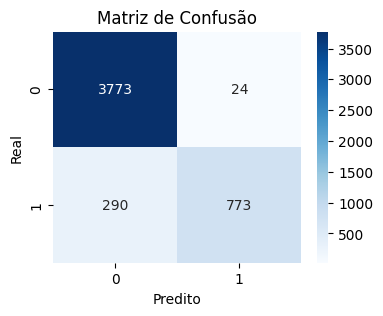

{'Model__subsample': 1.0, 'Model__n_estimators': 250, 'Model__max_depth': 7, 'Model__learning_rate': 0.05, 'Model__colsample_bytree': 1.0}


In [85]:
from sklearn.model_selection import RandomizedSearchCV

threshold = 0.5

model_final = ImbPipeline([
    ('preprocessor', preprocessor),
    ('Smote', SMOTE(random_state=42)),
    ('Model', XGBClassifier(random_state=42))
])

params = {
    'Model__n_estimators': [100, 150, 200, 250, 300],
    'Model__max_depth': [3, 4, 5, 7, 9],
    'Model__learning_rate': [0.03, 0.05, 0.1],
    'Model__subsample': [0.8, 1.0],
    'Model__colsample_bytree': [0.8, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=model_final,
    param_distributions=params,
    n_iter=20,
    scoring='precision',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_prob = best_model.predict_proba(X_val)[:,1]

y_pred = (y_prob >= threshold).astype(int)

acc = accuracy_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)


print("\n" + "="*60)
print("📌 Modelo: XGBoost")
print("="*60)

print(f'Acurácia de: {acc:.4f}\n')
print(f'ROC-AUC: {roc_auc:.4f}\n')
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

print(random_search.best_params_)

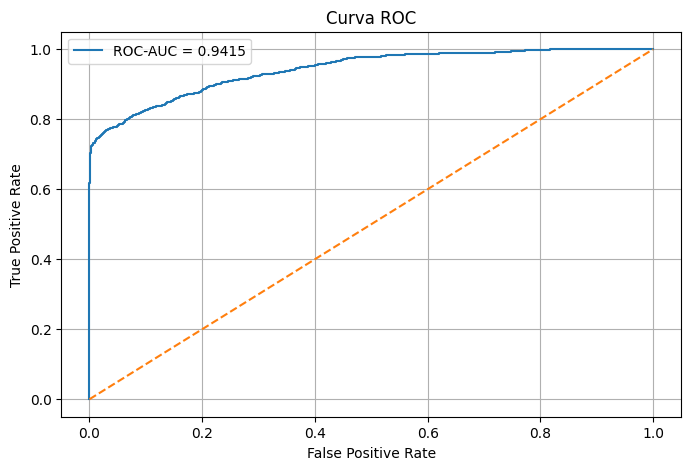

In [86]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_val, y_prob)
auc = roc_auc_score(y_val, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)

plt.show()

## Avaliação de Thresholds

Nesta etapa, diferentes valores de threshold serão testados para analisar seu impacto no desempenho do modelo e identificar o ponto de corte mais adequado para a classificação dos clientes.


In [87]:
resultados = []

thresholds = np.arange(0.1, 1.0, 0.05)

for threshold in thresholds:

    y_prob = best_model.predict_proba(X_val)[:,1]

    y_pred = (y_prob >= threshold).astype(int)

    resultados.append({
        'Threshold': threshold,
        'Precision': round(precision_score(y_val, y_pred), 4),
        'Recall': round(recall_score(y_val, y_pred), 4),
        'F1': round(f1_score(y_val, y_pred), 4),
        'Accuracy': round(accuracy_score(y_val, y_pred), 4)
    })

df_thresholds = pd.DataFrame(resultados)
df_thresholds = df_thresholds.set_index('Threshold')

df_thresholds.sort_values('F1', ascending=False)

,Precision,Recall,F1,Accuracy
Threshold,,,,
0.55,0.9821,0.7244,0.8338,0.9368
0.50,0.9699,0.7272,0.8312,0.9354
0.60,0.9845,0.7187,0.8309,0.9360
0.45,0.9537,0.7357,0.8306,0.9344
0.40,0.9308,0.7460,0.8282,0.9323
0.65,0.9882,0.7084,0.8252,0.9344
0.35,0.8958,0.7601,0.8224,0.9282
0.70,0.9907,0.7008,0.8209,0.9331
0.75,0.9920,0.6971,0.8188,0.9325


## Análise do Threshold

Para ilustrar o impacto do threshold no desempenho do modelo, foram avaliados diferentes valores de corte (0.05, 0.10, 0.25 e 0.50).

De forma geral, **thresholds menores aumentam o Recall da classe de inadimplentes**, permitindo identificar um número maior de clientes com risco de crédito. Em contrapartida, também aumentam a quantidade de falsos positivos, classificando mais clientes adimplentes como inadimplentes.

Já **thresholds maiores tornam o modelo mais conservador**, reduzindo os falsos positivos e aumentando a Precision, porém diminuindo a capacidade de identificar todos os clientes inadimplentes.

Essa análise evidencia o trade-off entre Precision e Recall, permitindo que a escolha do threshold seja feita de acordo com os objetivos do negócio.



📌 XGBoost: Threshold = 0.05  
Acurácia de: 0.4957

              precision    recall  f1-score   support

           0       0.99      0.36      0.53      3796
           1       0.30      0.99      0.46      1064

    accuracy                           0.50      4860
   macro avg       0.65      0.67      0.49      4860
weighted avg       0.84      0.50      0.51      4860



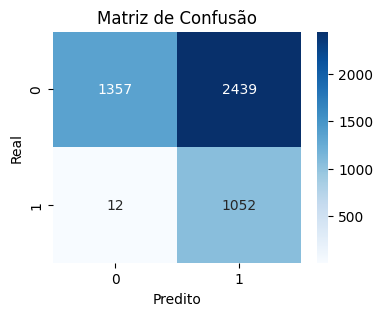


📌 XGBoost: Threshold = 0.1  
Acurácia de: 0.6780

              precision    recall  f1-score   support

           0       0.97      0.61      0.75      3796
           1       0.40      0.94      0.56      1064

    accuracy                           0.68      4860
   macro avg       0.69      0.77      0.65      4860
weighted avg       0.85      0.68      0.71      4860



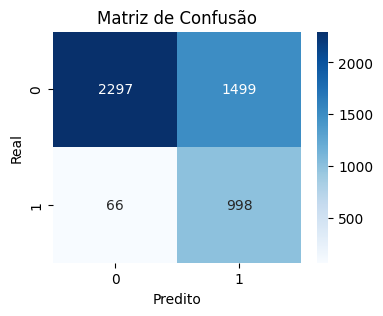


📌 XGBoost: Threshold = 0.25  
Acurácia de: 0.9010

              precision    recall  f1-score   support

           0       0.95      0.92      0.94      3796
           1       0.75      0.82      0.78      1064

    accuracy                           0.90      4860
   macro avg       0.85      0.87      0.86      4860
weighted avg       0.90      0.90      0.90      4860



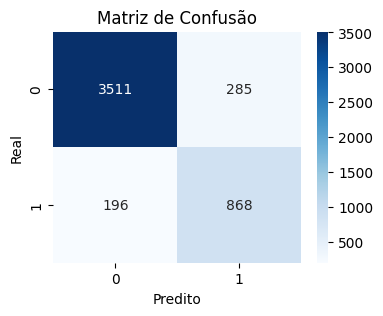


📌 XGBoost: Threshold = 0.5  
Acurácia de: 0.9360

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      3796
           1       0.96      0.74      0.83      1064

    accuracy                           0.94      4860
   macro avg       0.95      0.86      0.90      4860
weighted avg       0.94      0.94      0.93      4860



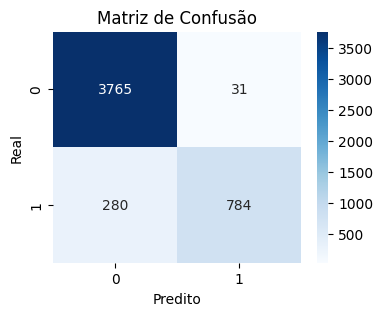

In [89]:
thresholds = [0.05, 0.1, 0.25, 0.5]

for thred in thresholds:
   y_prob = best_model.predict_proba(X_test)[:,1]

   y_pred = (y_prob >= thred).astype(int)

   acc = accuracy_score(y_test, y_pred)


   print("\n" + "="*60)
   print(f"📌 XGBoost: Threshold = {thred}  ")
   print("="*60)

   print(f'Acurácia de: {acc:.4f}\n')
   print(classification_report(y_test, y_pred))

   cm = confusion_matrix(y_test, y_pred)
   plt.figure(figsize=(4,3))
   sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
   plt.title("Matriz de Confusão")
   plt.xlabel("Predito")
   plt.ylabel("Real")
   plt.show()